### COMMON INSTRUCTIONS
Make sure to follow these instructions in order to ensure your submission is gradeable. If the automatic grading fails (check via Validate), no points are assigned!
1. Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).
2. Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".
3. If you work in a group, please always work and submit in a shared server under the name of your group.
   If you work alone, then always work and submit on the server called "My Server".
4. Using Large Language Models and other AI tools is discouraged. Do not paste external code, as it can be tracked!
5. Do not upload notebooks. Always work in notebooks on the server.
6. Do not copy cells inside a notebook. Add a new cell and copy code from another cell if needed.

In [1]:
!tar czf myfiles.tar.gz ./*

tar: ./myfiles.tar.gz: file changed as we read it


---

# eXplainable AI, Assignment 4
# Ulm University - Institute of Artificial Intelligence
# Summer Term 2026 - Due: Tue, May 12, 2026, 2pm - Moodle
(due to holiday the correction will take place together with sheet 5 on May 21)

# Data Preparation

Random Forests are a type of model which cannot be easily interpreted. We will work in the following with a random forest as black-box model.

In [3]:
!pip3 install pandas
import pandas as pd
!pip3 install numpy
import numpy as np
!pip3 install scikit-learn
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
!pip3 install matplotlib
import matplotlib.pyplot as plt

from typing import Callable

# For this notebook:
!pip3 install lime
!pip3 install torch torchvision pillow
!pip install shap==0.48.0

import torch  # used to define a simple DNN
import torchvision as tv  # we need the transforms and models submodules
from PIL import Image
import json
import urllib.request


  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
  Using cached matplotlib-3.10.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.met

In [8]:
df = pd.read_csv("housing_prices.csv", index_col=None)
NUMERICAL_COLUMNS = ['N_of_bedrooms', 'N_of_bathrooms', 'size_living',
       'size_lot', 'N_of_floors', 'condition', 'size_basement', 'yr_built']
TARGET_COLUMN = ['price']

df = df[NUMERICAL_COLUMNS + TARGET_COLUMN].dropna()

X = np.array(df[NUMERICAL_COLUMNS])
y = np.array(df[TARGET_COLUMN])
y = [val for sublist in y for val in sublist]

rf_regressor = RandomForestRegressor(max_depth=5, n_estimators=50, random_state=1337)
rf_regressor.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

# 1. LIME (7 pts)

## 1.1 Explaining Tabular Data with LIME (2pts)

We want to explain the housing price prediction made by the trained `rf_regressor` on the given input instance.

Use LIME (implementation at https://github.com/marcotcr/lime) for tabular data with linear regression as surrogate model.
Plot the explanation (feature relevances against feature names).

*Hints:* You may use the `NUMERICAL_COLUMNS` and `TARGET_COLUMN` variables for specifying the feature and class names (do not discretize).

,N_of_bedrooms,N_of_bathrooms,size_living,size_lot,N_of_floors,condition,size_basement,yr_built
0,5.00,2.75,333.99,523.88,2.00,3.00,0.00,2014.00


Intercept 564505.8928411879
Prediction_local [945334.00045768]
Right: 850888.0590752242
size_living: 262243.8296
yr_built: -60192.4675
size_lot: -26333.1890
N_of_bathrooms: 7442.6072
N_of_floors: 4026.9139
condition: 3912.8526
N_of_bedrooms: -2289.7342
size_basement: 216.2904


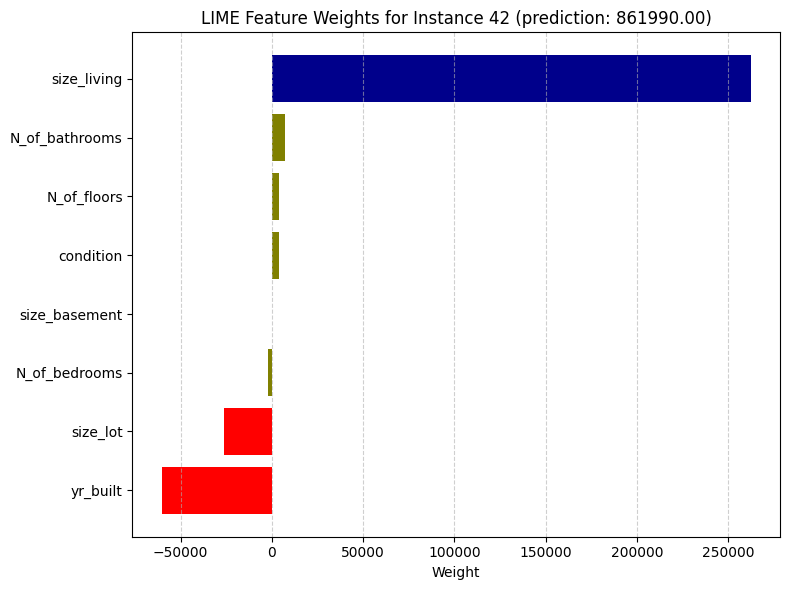

In [11]:
from lime import lime_tabular

instance_id = 42
instance = X[instance_id]
output = y[instance_id]
# Inspect the instance
display(pd.DataFrame(instance, index=NUMERICAL_COLUMNS).T.style.set_caption(f"Instance with ID {instance_id} (prediction {output:.2f})").format('{:.2f}'))

def explain_instance_lime(instance: np.ndarray) -> tuple[list[str], list[float]]:
    """For the given table row `instance`, return the lists of features and their relevances.
    Features and relevance are sorted descending by relevance (most relevant first).
    """
    features, relevances = None, None
    
    ### BEGIN SOLUTION
    # Create the explainer
    explainer = lime_tabular.LimeTabularExplainer(X, feature_names=NUMERICAL_COLUMNS, class_names=TARGET_COLUMN, discretize_continuous=False, verbose=True, mode='regression')
    
    # Explaining an instance
    #instance_id = np.random.randint(0, X.shape[0])
    exp = explainer.explain_instance(instance, rf_regressor.predict,
                                     num_features=len(NUMERICAL_COLUMNS),
                                     top_labels=1)
    
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")
    
    # Get the explanation as a list of (feature_name, weight) tuples and sort descending by relevance
    weights = exp.as_list()
    weights = sorted(weights, key = lambda x: x[-1], reverse=True)
    
    # Separate feature names and their weights
    features, relevances = zip(*weights)
    ### END SOLUTION
    
    return features, relevances
    
features, relevances = explain_instance_lime(instance)

# Plot horizontal bar chart
### BEGIN SOLUTION
colors = ["red" if w < lower_thresh else "olive" if (w>=lower_thresh and w<=upper_thresh) else "darkblue" for w in relevances]

plt.figure(figsize=(8, 6))
plt.barh(features, relevances, color=colors)
plt.xlabel("Weight")
plt.title(f"LIME Feature Weights for Instance {instance_id} (prediction: {output:.2f})")
plt.gca().invert_yaxis()  # Optional: top feature at the top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show() 
### END SOLUTION

,N_of_bedrooms,N_of_bathrooms,size_living,size_lot,N_of_floors,condition,size_basement,yr_built
0,5.00,2.75,333.99,523.88,2.00,3.00,0.00,2014.00


Task was destroyed but it is pending!
task: <Task pending name='Task-194' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/conda/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-195' coro=<Kernel.shell_main() running at /opt/conda/lib/python3.13/site-packages/ipykernel/kernelbase.py:590> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/conda/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/conda/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:43: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = getattr(arr, method)(*args, **kwds)
Task was destroyed but it is pending!
task: <Task pending name='Task-195' coro=<Kernel.shell_main() running at /opt/conda/lib/python3.13/site-packages/ipykernel/kernelbase.py:590> cb=[Task.task_wakeup()]>


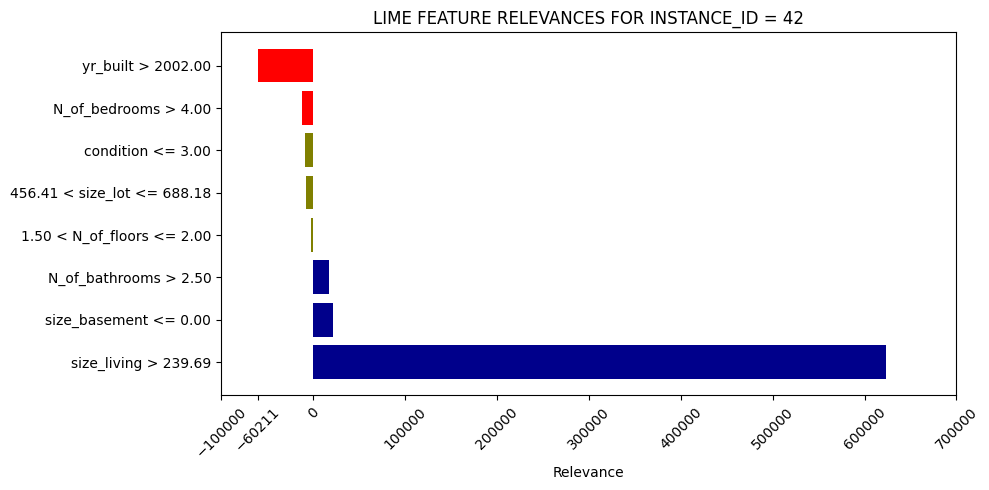

Success!


In [22]:
from lime import lime_tabular

instance_id = 42
instance = X[instance_id]
output = y[instance_id]
# Inspect the instance
display(
    pd.DataFrame(instance, index=NUMERICAL_COLUMNS)
    .T.style.set_caption(f"Instance with ID {instance_id} (prediction {output:.2f})")
    .format("{:.2f}")
)


def explain_instance_lime(instance: np.ndarray) -> tuple[list[str], list[float]]:
    """For the given table row `instance`, return the lists of features and their relevances.
    Features and relevance are sorted descending by relevance (most relevant first).
    """
    features, relevances = None, None

    # YOUR SOLUTION HERE
    explainer = lime_tabular.LimeTabularExplainer(
        training_data=X,
        feature_names=NUMERICAL_COLUMNS,
        mode="regression",
        # discrete_continuous=False
    )
    explanation = explainer.explain_instance(
        instance, rf_regressor.predict, num_features=len(NUMERICAL_COLUMNS)
    )
    explanation_list = explanation.as_list()
    explanation_list_sorted = sorted(explanation_list, key=lambda x: x[1], reverse=True)
    features = [e[0] for e in explanation_list_sorted]
    relevances = [e[1] for e in explanation_list_sorted]
    return features, relevances


features, relevances = explain_instance_lime(instance)

# Plot horizontal bar chart
# YOUR SOLUTION HERE
plt.figure(figsize=(10, 5))
#get min & max for better visualization of "near 0"
min_rel = min(relevances)
max_rel = max(relevances)
lower_thresh = -1 * abs(max_rel*0.015) # could pick a fraction of abs max of negative or positive relevances here, or mean, or
upper_thresh = max_rel*0.015 # or only a fraction of either/or negative
#print(lower_thresh)
#print(upper_thresh)
colors = ["red" if w < lower_thresh else "olive" if (w>=lower_thresh and w<=upper_thresh) else "darkblue" for w in relevances]
plt.barh(features, relevances, color=colors)
plt.xlabel("Relevance")
plt.title(f"LIME FEATURE RELEVANCES FOR INSTANCE_ID = {instance_id}")
plt.axvline(0, color="black", linewidth=0.0001) # thin line / nonexistant line to still see the tiny olive-colored "irrelevant" bars
plt.xticks([min(relevances)] + list(plt.xticks()[0]), rotation=45 ) # we'd like to see the max negative relevance effect on the left
plt.tight_layout()
plt.show()

# (hidden tests)
print("Success!")

## 1.2 Interpreting local feature importance explanations (2pts)

Now interpret the values obtained in the explanation above:
1. Which feature has the biggest relevance, which the smallest (i.e., most negative)? What does that mean (assuming good monotonicity and sensitivity-n)?
2. What should a relevance close to zero mean?
3. How simple is that explanation for a (novice) user? 

YOUR ANSWER HERE
1. Size-living is significantly positively relevant (orders of magnitude above the next feature, N_of_bathrooms)
   size_basement has the lowest relevance value
2. That the feature has nearly no effect on the model's output -> close-to-0 relevance = irrelevant for output
3. Very simple, especially with the visualization clearly indicating an "important of each feature on average" based on the size of the bar & its negative/positive prediction impact (here additionally marked with colors)


## 1.3 A closer look at explanation selectivity (1pt)

In the lecture we have seen a plot to illustrate explanation selectivity (# removed features, ordered ascending by relevance, against model output). The method plotted here only produces positive feature relevance values.
LIME instead also returns negative feature relevances.
How do you expect an explanation selectivity plot to look like for a sample where all of strongly positive, near-zero, and strongly negative feature relevances occur?

YOUR ANSWER HERE
Having multiple colors, 1 each for the strongly-pos / near-zero / strongly nev feature relevances - like done above!

## 1.2 Explaining Image Classification with LIME — Playground (2 pts)
LIME can be applied to all kinds of domains, as long your are able to provide an interpretable instance (a feature definition) of the input. In this exercise we want to take a look at images.

1. Use the black-box model (see below) and the offical lime library to explain the top-1 prediction of the provided cat image.
2. Show which parts of the image positively and negatively contribute to the prediction: use the `LimeImageExplainer` API and `mark_boundaries` to obtain and plot the feature mask.

*Hints*: Check out the `lime_image.LimeImageExplainer` and `lime.wrappers.scikit_image.SegmentationAlgorithm` interfaces. Mind the API: LIME expects a function that receives and returns numpy arrays (not torch tensors).

/opt/conda/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


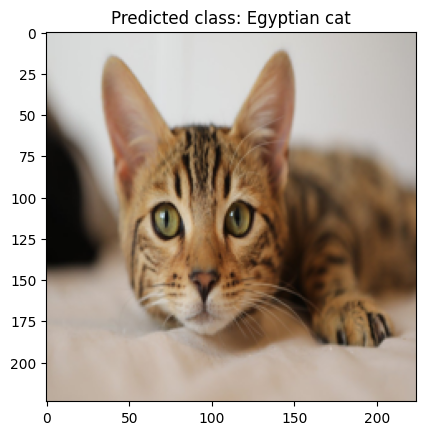

In [17]:
# Load pretrained MobileNetV2
model: Callable[[torch.tensor], torch.tensor] = tv.models.mobilenet_v2(weights=True)
model.eval()

# Load ImageNet class labels (for nicer names when interpreting the predictions)
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = urllib.request.urlopen(url).read().decode("utf-8").splitlines()

# Define input transformation
transform = tv.transforms.Compose([
    tv.transforms.Resize((224, 224)),
    tv.transforms.ToTensor(),
    tv.transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load and preprocess image
cat_image: Image = Image.open("cat.jpg").convert("RGB").resize((224, 224))
cat_image_array: np.ndarray = np.array(cat_image)

# Run prediction
with torch.no_grad():
    # convert numpy to tensor and add batch dimension
    input_tensor = transform(Image.fromarray(cat_image_array.astype(np.uint8))).unsqueeze(0)
    # actual model prediction
    outputs = model(input_tensor)
    _, predicted_idx = outputs.max(1)
    predicted_label = imagenet_classes[predicted_idx.item()]

_ = plt.imshow(cat_image)
_ = plt.title(f"Predicted class: {predicted_label}")

In [18]:
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm  # e.g., 'quickshift', 'slic', 'felzenszwalb' algorithms
from skimage.segmentation import mark_boundaries

# Define prediction function for LIME
def model_predict_fn(images_batch: np.ndarray) -> np.ndarray:
    """Wrap the model from above to receive and return numpy arrays."""
    outputs: np.ndarray = None
    # YOUR SOLUTION HERE
    batch_tensor = torch.stack([
        transform(Image.fromarray(img.astype(np.uint8)))
            for img in images_batch
    ])
    with torch.no_grad():
        logits = model(batch_tensor)
        outputs = torch.nn.functional.softmax(logits, dim=1).numpy()
    return outputs


# Create explainer and segmenter
explanation: lime_image.ImageExplanation = None
# YOUR SOLUTION HERE
lime_image_explainer = lime_image.LimeImageExplainer()
segmenter = SegmentationAlgorithm('quickshift', kernel_size=4, max_dist=200, ratio=0.2)

explanation = lime_image_explainer.explain_instance(
    cat_image_array.astype(np.double),
    model_predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=segmenter)
print('LIME explanation top labels are:', explanation.top_labels)

  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation top labels are: [np.int64(285)]


In [7]:
# (hidden tests)
print('Success!')

Success!


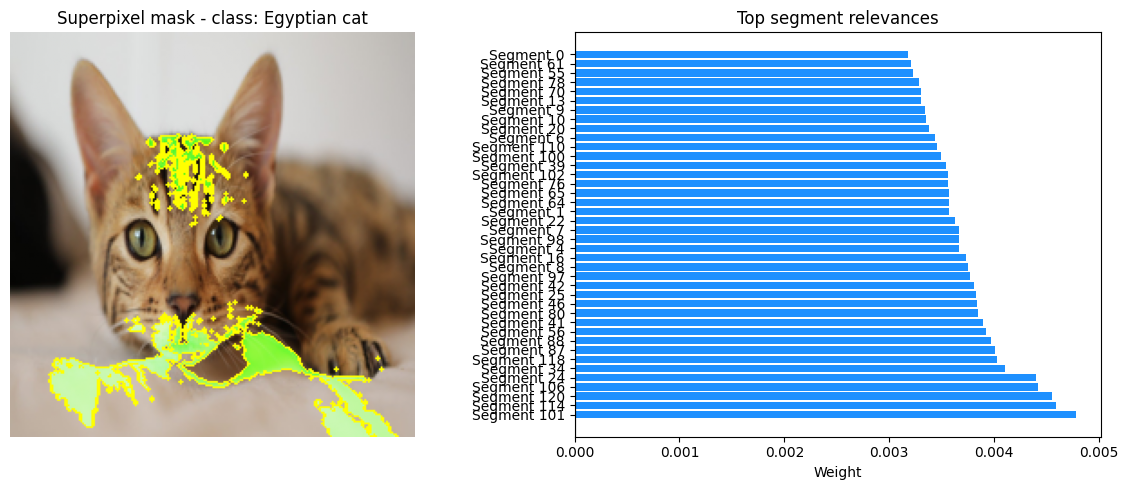

In [21]:
# (continuing in separate cell since large numbers of samples can make the previous one slow)

# Plot feature weights (bar chart)
# YOUR SOLUTION HERE
top_label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=False,
    num_features=5,
    hide_rest=False
)

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].imshow(mark_boundaries(temp / 255.0, mask))
axes[0].set_title(f"Superpixel mask - class: {imagenet_classes[top_label]}")
axes[0].axis('off')

weights = explanation.local_exp[top_label]
seg_ids = [w[0] for w in weights[:40]]
seg_vals = [w[1] for w in weights[:40]]
colors = np.array(['dodgerblue' if v > 0 else 'crimson' for v in seg_vals]) #needs to be a np array for some reason
axes[1].barh([f'Segment {s}' for s in seg_ids], seg_vals, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Weight")
axes[1].set_title("Top segment relevances")
plt.tight_layout()
plt.show()

## Bonus: LIME Playground
In the above explanation, test out the influence of
- the **number of generated samples** for LIME fitting,
- **feature definition:** the choice of segmentation algorithm,
- the **distance metric** used to compare generated images with the original.

You may share any observations of the playground below.

YOUR ANSWER HERE
lowering num_samples
-expectation: lower the "resolution" of segments, maybe grouping regions together
-results: actually seems to maybe not sample enough times -> doesn't even find relevant areas of the image containing cat features. seems to use the surrounding's features instead of the cat a lot more often! (over multiple re-sample runs)

# 2. Shapley Values and SHAP (5 pts)

## 2.1 Shapley Values (2 pts)

In the following we will go in more depth through an example of Shapley value calculation.

> The managing board of a corporation consists of three stock-holders who have respectively 20, 30 and 50 shares of stock, and the chairman who has no shares. Any decision can be settled by approval of board members holding a simple majority of the shares and the chairman can decide tie votes. Thus, the characteristic function can be defined as follows: It has value 1 if a coalition holds > 50 shares or holds ≥ 50 shares and has the chairman in the coalition. It has value 0 otherwise.

Model the situation as a cooperative game (what is payoff, agents, coalitions, and value distribution?) and find the Shapley values for the stock-holders.


YOUR ANSWER HERE
COOP game model:
Agents: A (20 shares) | B (30 shares) | C (50 shares) | Chairman (0 shares)
Payoff: -> 1 if decision passes 
        -> 0 otherwise
Coalitions: any combination of the 4 agents in a subset
Value function: s =^= coalition
v(S) -> 1 if shares(S) > 50 OR shares(S) == 50 && CHAIRMAN ∈ S
-> 0 otherwise

1. A(20) only in one scenario pivotal: (B,C)>50 -> only adds | (C,ch)>=50 -> only adds | (C)=50, +(A)=20 -> v=1 <br>
2. B(30) same but inverted A & B roles for in each coalition example <br>
3. C(50) pivotal: (Ch) -> C(50) -> v=1 | (A,ch)=20 -> C(50) -> value=1 | (B,ch)=30 -> (50) -> value=1 | (A,B)=50 -> C(50) -> value=1 <br>
4. Ch(0) is pivotal for colitions: (A,B)=50 -> +Ch -> v=1 | (C)=50 -> +Ch -> v=1 <br>

Winning coalitions: (A,B,C), (B,C), (A,C,Ch), (B,C,CH), (A,B,C,Ch), (C,Ch), (A,C), (A,B,Ch)<br>
combinations of orders: 4! = 24 <br>
φ(A): 2 permutations for pivotal choice: (C,A,B,Ch) & (C,A,Ch,B) -> joins (C) coalition<br>
φ(B) equivalent to above -> φ(A)=φ(B)=2/24=1/12<br>
φ(Ch): 6 permutations for pivotal choice: (A,B,Ch,C), (B,A,Ch,C), (C,Ch,A,B), (C,Ch,B,A), (A,C,Ch,B), (B,C,Ch,A) -> φ(Ch) 3/12<br>
φ(C) -> is the rest (12-5)/12 = 7/12<br>

φ(A) = 1/12 = 0.08333..<br>
φ(B) = 1/12 = 0.08333..<br>
φ(C) = 7/12 = 0.58333..<br>
φ(Ch) = 3/12 = 0.25<br>


## 2.2 KernelSHAP Runtime Complexity (0.5 pts)

KernelSHAP samples from all possible coalitions. Unfortunately, the number of coalitions increases exponentially in the number of features. Assume you have only a limited time budget. Given what you know about how the Shapley values are computed: What might be a smart way of choosing which coalitions to sample from first?
Which coalitions most strongly contribute to the final Shapley value of a feature?

YOUR ANSWER HERE<br>
(typo: exponentially with the numbers of features)<br>
the weighting kernel in KernelSHAP seems to asign the smallest & largest coalitions (size=1, size=n-1) the largest weight values<br>
Intuition: start at s=1 & s=n-1, then s=1+i & s=n-1-i iteratively incrementing i+1<br> 

## 2.3 Local-to-Global Explanations: Summary Plots (1 + 1 pts)

If we collect the SHAP values of features for several samples, one can also produce global explanations via aggregation or summary plotting. A commonly used SHAP plot is the so-called `beeswarm` (formerly known as `summary_plot`). Explain the housing dataset for the random forest regressor above using SHAP, and plot a `beeswarm` plot of the result.  
*About `beeswarm` summary plots:* This plot allows a global view on the model. The y-axis is each feature, ordered by their global importance. The x-axis is the respective SHAP value. Points inside a row are datapoints, so a single point is the respective SHAP value of that feature for that datapoint. It is colored by the relative feature value (each row individually).

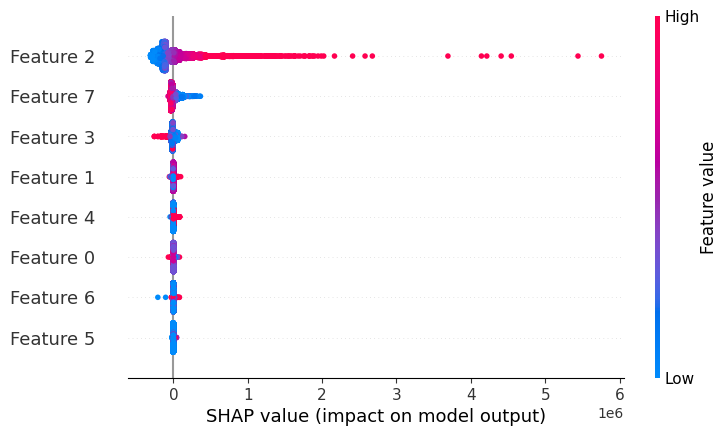

In [9]:
import shap
# explain using SHAP and visualize via beeswarm plot
# YOUR SOLUTION HERE
explainer_shap = shap.TreeExplainer(rf_regressor)
shap_values_beeswarm = explainer_shap(X)
shap.plots.beeswarm(shap_values_beeswarm)

Now revisit the formal properties of Shapley values that guarantee their uniqueness: Which of them makes Shapley values particularly suited to provide global explanations, i.e., simultaneously consider Shapley values of different samples (with different predictions)?

Note that other methods like vanilla LIME miss this property, making it less reasonable to accumulate their relevances globally.

Relevant property (and why):
YOUR ANSWER HERE

# 2.4 Local-to-Global explanations: Dependence Plots (0.5 pts)

The last type of plot we want to highlight in this exercise is the `dependence_plot`. Please plot a SHAP dependence plot for the feature `size_living` of the housing dataset.  
*About SHAP dependence plots:* It plots as scatter plot the feature's value in each datapoint against the SHAP value for each point. They are typically colored with the value range of a second feature (`rooms` in this case), which has the highest SHAP interaction value.


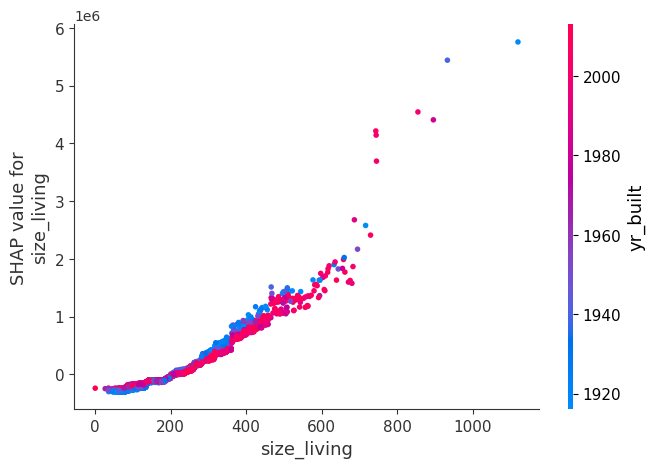

In [10]:
import shap
shap_values: shap._explanation.Explanation = None
# YOUR SOLUTION HERE
shap_values = explainer_shap(X)
shap.dependence_plot("size_living", shap_values.values, pd.DataFrame(X,columns=NUMERICAL_COLUMNS))

# 3. Bonus: More SHAP Plotting via Force Plots

For local explanations, so-called `force` plots are helpful to visualize feature importance.
Please explain now the 22nd datapoint (`X.iloc[21,:])` in the data with the `force` plot from SHAP.

What can you see in the plot?

*Hint:* If you have problems with rendering, use `matplotlib=True`.

,N_of_bedrooms,N_of_bathrooms,size_living,size_lot,N_of_floors,condition,size_basement,yr_built
0,3.0,2.75,283.35,4168.28,1.0,3.0,66.89,1968.0


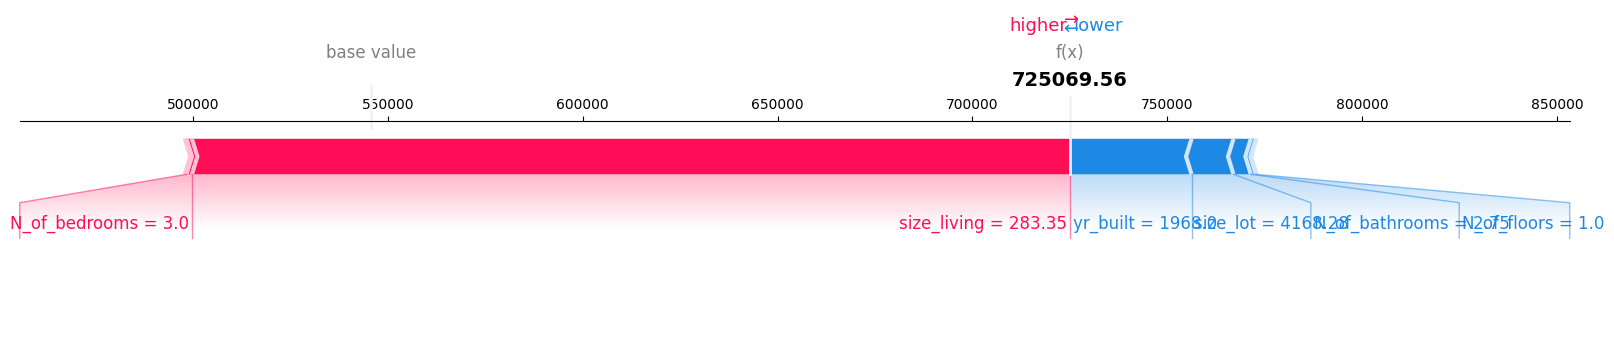

In [11]:
# Solution
import shap

# Inspect the instance
display(pd.DataFrame(X[21], index=NUMERICAL_COLUMNS).T)

# YOUR SOLUTION HERE
half_the_answer_to_everything = 21
shap_values_local = explainer_shap(X)

shap.force_plot(
    shap_values_local.base_values[half_the_answer_to_everything],
    shap_values_local.values[half_the_answer_to_everything],
    pd.DataFrame(X, columns=NUMERICAL_COLUMNS).iloc[half_the_answer_to_everything],
    matplotlib=True
               )